# Student Performance Data Analysis

## Overview
This notebook explores the Student Performance dataset using Python. We will follow the data science workflow: **load → clean → analyze → visualize → conclude**.

### Skills Covered
✓ Data loading & cleaning (Pandas)
✓ Statistical analysis with NumPy
✓ Data visualization with Matplotlib/Seaborn
✓ Correlation analysis
✓ Jupyter Notebook documentation

---

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## 2. Load Dataset

We use pandas to read the `student-mat.csv` file. Note: The CSV uses semicolon (`;`) as delimiter.

In [3]:
# Load the dataset
df = pd.read_csv('student-mat.csv', sep=';')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nFirst few rows:")
df.head()

Dataset loaded successfully!
Shape: 395 rows × 33 columns

First few rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 3. Explore & Clean Data

### 3.1 Dataset Overview

In [4]:
# Display column names and data types
print("Column Names:")
print(df.columns.tolist())
print(f"\nData Types:\n")
print(df.dtypes)

Column Names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Data Types:

school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3  

### 3.2 Check for Missing Values

In [5]:
# Check missing values
missing_values = df.isnull().sum()
print("Missing Values:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "✓ No missing values found!")

Missing Values:
✓ No missing values found!


### 3.3 Check for Duplicates

In [6]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"✓ Duplicates removed! New shape: {df.shape}")
else:
    print("✓ No duplicates found!")

Duplicate Rows: 0
✓ No duplicates found!


### 3.4 Dataset Statistics

In [7]:
# Display statistical summary
print("Statistical Summary:")
df.describe()

Statistical Summary:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


---
## 4. Analysis Questions

### Q1: What is the average final grade (G3)?

In [8]:
# Calculate average final grade
avg_grade = df['G3'].mean()
print(f"Average Final Grade (G3): {avg_grade:.2f}")
print(f"Median: {df['G3'].median():.2f}")
print(f"Standard Deviation: {df['G3'].std():.2f}")
print(f"Range: {df['G3'].min()} to {df['G3'].max()}")

Average Final Grade (G3): 10.42
Median: 11.00
Standard Deviation: 4.58
Range: 0 to 20


### Q2: How many students scored above 15?

In [9]:
# Count students scoring above 15
above_15 = (df['G3'] > 15).sum()
percentage = (above_15 / len(df)) * 100

print(f"Students who scored above 15: {above_15}")
print(f"Percentage: {percentage:.1f}%")
print(f"Total students: {len(df)}")

Students who scored above 15: 40
Percentage: 10.1%
Total students: 395


### Q3: Is study time correlated with performance?

In [10]:
# Calculate correlation between study time and grades
correlation = df['studytime'].corr(df['G3'])

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(df['studytime'], df['G3'])

print(f"Pearson Correlation Coefficient: {correlation:.4f}")
print(f"R² Value: {r_value**2:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Statistically Significant: {'Yes' if p_value < 0.05 else 'No'}")

if correlation > 0:
    print(f"\n✓ Positive Correlation: More study time is associated with higher grades")
else:
    print(f"\n✓ Negative Correlation: Less study time is associated with higher grades")

Pearson Correlation Coefficient: 0.0978
R² Value: 0.0096
P-value: 0.052061
Statistically Significant: No

✓ Positive Correlation: More study time is associated with higher grades


### Q4: Which gender performs better on average?

In [11]:
# Analyze performance by gender
gender_performance = df.groupby('sex')['G3'].agg(['mean', 'median', 'std', 'count'])
print("Performance by Gender:")
print(gender_performance)
print()

best_gender = gender_performance['mean'].idxmax()
best_score = gender_performance.loc[best_gender, 'mean']
print(f"✓ Best performing gender: {best_gender} (Average: {best_score:.2f})")

# Gender mapping for readability
gender_map = {'F': 'Female', 'M': 'Male'}
print(f"   {gender_map.get(best_gender, best_gender)} students perform better on average.")

Performance by Gender:
          mean  median       std  count
sex                                    
F     9.966346    10.0  4.622338    208
M    10.914439    11.0  4.495297    187

✓ Best performing gender: M (Average: 10.91)
   Male students perform better on average.


---
## 5. Visualizations

### Visualization 1: Histogram of Grades

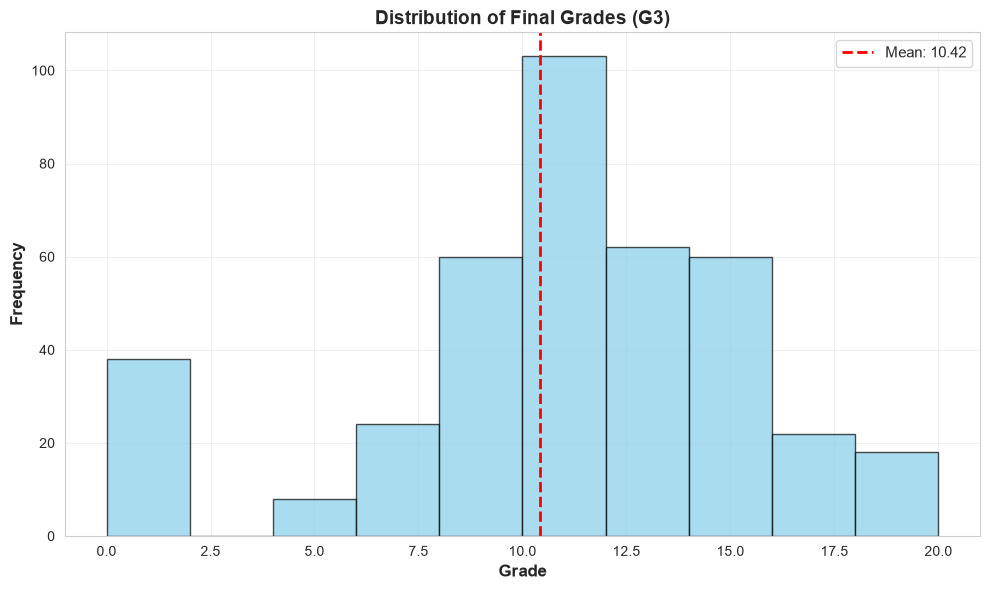

In [12]:
# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(df['G3'], bins=10, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(avg_grade, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_grade:.2f}')
plt.xlabel('Grade', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Distribution of Final Grades (G3)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Visualization 2: Scatterplot - Study Time vs Grades

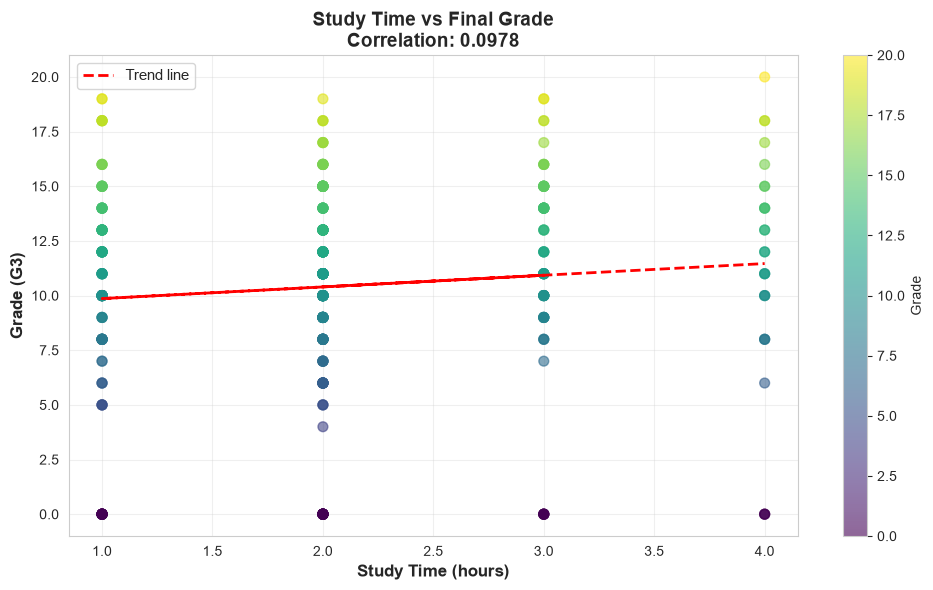

In [13]:
# Create scatterplot with trend line
plt.figure(figsize=(10, 6))
plt.scatter(df['studytime'], df['G3'], alpha=0.6, s=50, c=df['G3'], cmap='viridis')

# Add trend line
z = np.polyfit(df['studytime'], df['G3'], 1)
p = np.poly1d(z)
plt.plot(df['studytime'].unique(), p(df['studytime'].unique()), "r--", linewidth=2, label='Trend line')

plt.xlabel('Study Time (hours)', fontsize=12, fontweight='bold')
plt.ylabel('Grade (G3)', fontsize=12, fontweight='bold')
plt.title(f'Study Time vs Final Grade\nCorrelation: {correlation:.4f}', fontsize=14, fontweight='bold')
plt.colorbar(label='Grade')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Visualization 3: Bar Chart - Male vs Female Average Score

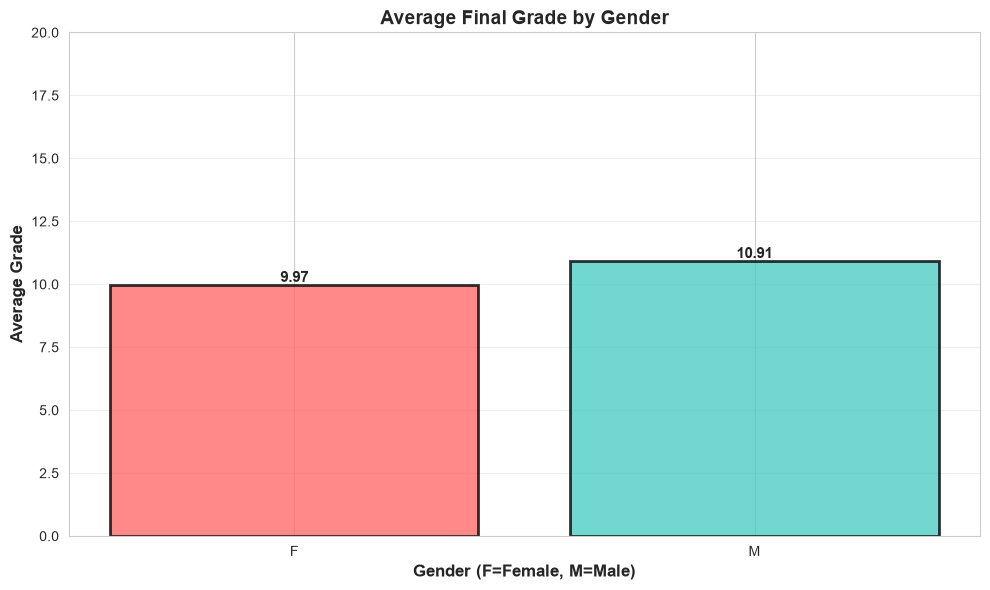

In [14]:
# Create bar chart
plt.figure(figsize=(10, 6))
gender_means = df.groupby('sex')['G3'].mean()
colors = ['#FF6B6B', '#4ECDC4']
bars = plt.bar(gender_means.index, gender_means.values, color=colors, alpha=0.8, edgecolor='black', linewidth=2)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.ylabel('Average Grade', fontsize=12, fontweight='bold')
plt.xlabel('Gender (F=Female, M=Male)', fontsize=12, fontweight='bold')
plt.title('Average Final Grade by Gender', fontsize=14, fontweight='bold')
plt.ylim([0, 20])
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Visualization 4: Box Plot - Grade Distribution by Gender

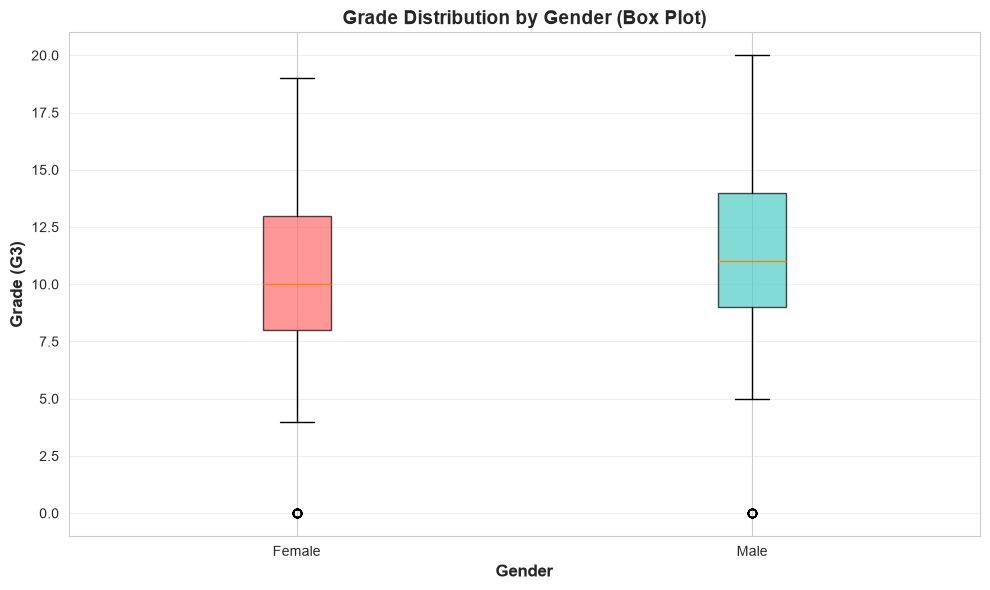

In [16]:
# Create box plot
plt.figure(figsize=(10, 6))
data_by_gender = [df[df['sex'] == gender]['G3'].values for gender in ['F', 'M']]
bp = plt.boxplot(
    data_by_gender,
    tick_labels=['Female', 'Male'],
    patch_artist=True
)

for patch, color in zip(bp['boxes'], ['#FF6B6B', '#4ECDC4']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.ylabel('Grade (G3)', fontsize=12, fontweight='bold')
plt.xlabel('Gender', fontsize=12, fontweight='bold')
plt.title('Grade Distribution by Gender (Box Plot)', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Visualization 5: Comprehensive Dashboard

C:\Users\aaron\AppData\Local\Temp\ipykernel_7896\1763191005.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\aaron\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 9670 (\N{BLACK DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


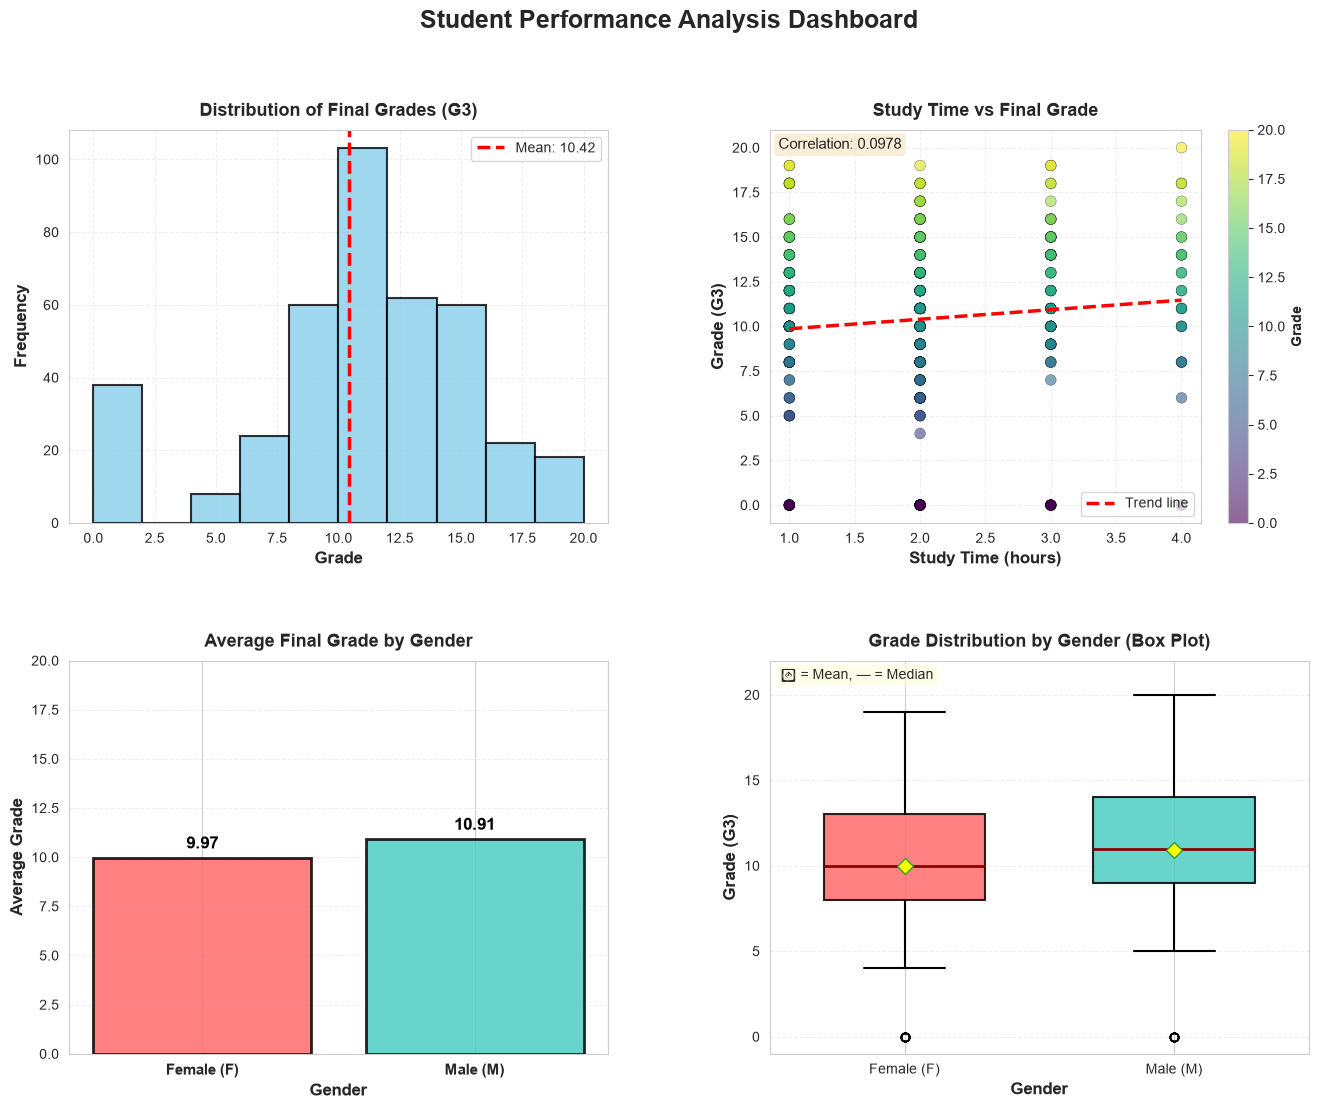

✓ Dashboard created successfully!


In [17]:
# Create a comprehensive dashboard with improved layout
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)
fig.suptitle('Student Performance Analysis Dashboard', fontsize=18, fontweight='bold', y=0.98)

# Plot 1: Histogram
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df['G3'], bins=10, color='skyblue', edgecolor='black', alpha=0.8, linewidth=1.5)
ax1.axvline(avg_grade, color='red', linestyle='--', linewidth=2.5, label=f'Mean: {avg_grade:.2f}')
ax1.set_xlabel('Grade', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Final Grades (G3)', fontsize=13, fontweight='bold', pad=10)
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# Plot 2: Scatterplot
ax2 = fig.add_subplot(gs[0, 1])
scatter = ax2.scatter(df['studytime'], df['G3'], alpha=0.6, s=60, c=df['G3'], 
                      cmap='viridis', edgecolors='black', linewidth=0.3)
z = np.polyfit(df['studytime'], df['G3'], 1)
p = np.poly1d(z)
x_line = np.array(sorted(df['studytime'].unique()))
ax2.plot(x_line, p(x_line), "r--", linewidth=2.5, label='Trend line')
ax2.set_xlabel('Study Time (hours)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Grade (G3)', fontsize=12, fontweight='bold')
ax2.set_title('Study Time vs Final Grade', fontsize=13, fontweight='bold', pad=10)
ax2.text(0.02, 0.98, f'Correlation: {correlation:.4f}', transform=ax2.transAxes,
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax2.legend(fontsize=10, loc='lower right')
ax2.grid(alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Grade', fontweight='bold', fontsize=10)

# Plot 3: Bar chart
ax3 = fig.add_subplot(gs[1, 0])
gender_means = df.groupby('sex')['G3'].mean()
gender_labels = ['Female (F)', 'Male (M)']
colors = ['#FF6B6B', '#4ECDC4']
bars = ax3.bar(range(len(gender_means)), gender_means.values, color=colors, 
               alpha=0.85, edgecolor='black', linewidth=2)
ax3.set_xticks(range(len(gender_means)))
ax3.set_xticklabels(gender_labels, fontsize=11, fontweight='bold')
ax3.set_ylabel('Average Grade', fontsize=12, fontweight='bold')
ax3.set_xlabel('Gender', fontsize=12, fontweight='bold')
ax3.set_title('Average Final Grade by Gender', fontsize=13, fontweight='bold', pad=10)
ax3.set_ylim([0, 20])
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.3, f'{height:.2f}',
            ha='center', va='bottom', fontweight='bold', fontsize=12, color='black')
ax3.grid(alpha=0.3, axis='y', linestyle='--')
ax3.set_axisbelow(True)

# Plot 4: Box plot
ax4 = fig.add_subplot(gs[1, 1])
data_by_gender = [df[df['sex'] == gender]['G3'].values for gender in ['F', 'M']]
bp = ax4.boxplot(data_by_gender, tick_labels=['Female (F)', 'Male (M)'], 
                  patch_artist=True, widths=0.6, showmeans=True,
                  meanprops=dict(marker='D', markerfacecolor='yellow', markersize=8))
for patch, color in zip(bp['boxes'], ['#FF6B6B', '#4ECDC4']):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
    patch.set_linewidth(1.5)
for element in ['whiskers', 'fliers', 'means', 'medians', 'caps']:
    plt.setp(bp[element], linewidth=1.5)
plt.setp(bp['medians'], color='darkred', linewidth=2)
ax4.set_ylabel('Grade (G3)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Gender', fontsize=12, fontweight='bold')
ax4.set_title('Grade Distribution by Gender (Box Plot)', fontsize=13, fontweight='bold', pad=10)
ax4.set_ylim([-1, 22])
ax4.grid(alpha=0.3, axis='y', linestyle='--')
ax4.set_axisbelow(True)
ax4.text(0.02, 0.98, '◆ = Mean, — = Median', transform=ax4.transAxes,
         fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.tight_layout()
plt.show()

print("✓ Dashboard created successfully!")

---
## 6. Summary & Conclusions

In [18]:
print("""
═══════════════════════════════════════════════════════════════════
                      KEY FINDINGS SUMMARY
═══════════════════════════════════════════════════════════════════

1. AVERAGE PERFORMANCE
   ├─ Mean Grade: {:.2f}
   ├─ Median Grade: {:.2f}
   ├─ Std Deviation: {:.2f}
   └─ Range: {} to {}

2. HIGH ACHIEVERS
   ├─ Students scoring above 15: {}
   └─ Percentage: {:.1f}%

3. STUDY TIME IMPACT
   ├─ Correlation Coefficient: {:.4f}
   ├─ R² Value: {:.4f}
   ├─ P-value: {:.6f}
   └─ Significance: {}

4. GENDER COMPARISON
   ├─ Female Average: {:.2f}
   ├─ Male Average: {:.2f}
   └─ Better Performer: {}

5. DATASET QUALITY
   ├─ Total Records: {}
   ├─ Missing Values: {}
   └─ Duplicates Removed: {}

═══════════════════════════════════════════════════════════════════
✓ ANALYSIS COMPLETE!
═══════════════════════════════════════════════════════════════════
""".format(
    avg_grade,
    df['G3'].median(),
    df['G3'].std(),
    df['G3'].min(),
    df['G3'].max(),
    above_15,
    percentage,
    correlation,
    r_value**2,
    p_value,
    'Significant' if p_value < 0.05 else 'Not Significant',
    gender_performance.loc['F', 'mean'],
    gender_performance.loc['M', 'mean'],
    best_gender,
    len(df),
    missing_values.sum(),
    duplicates
))


═══════════════════════════════════════════════════════════════════
                      KEY FINDINGS SUMMARY
═══════════════════════════════════════════════════════════════════

1. AVERAGE PERFORMANCE
   ├─ Mean Grade: 10.42
   ├─ Median Grade: 11.00
   ├─ Std Deviation: 4.58
   └─ Range: 0 to 20

2. HIGH ACHIEVERS
   ├─ Students scoring above 15: 40
   └─ Percentage: 10.1%

3. STUDY TIME IMPACT
   ├─ Correlation Coefficient: 0.0978
   ├─ R² Value: 0.0096
   ├─ P-value: 0.052061
   └─ Significance: Not Significant

4. GENDER COMPARISON
   ├─ Female Average: 9.97
   ├─ Male Average: 10.91
   └─ Better Performer: M

5. DATASET QUALITY
   ├─ Total Records: 395
   ├─ Missing Values: 0
   └─ Duplicates Removed: 0

═══════════════════════════════════════════════════════════════════
✓ ANALYSIS COMPLETE!
═══════════════════════════════════════════════════════════════════

